In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import math
from fractions import Fraction

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from surrogate_matlab import *
from fda_rof_funcs_v2 import *
import torch
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(torch.float64)

print("device:", device)


device: cuda


In [3]:
class FDAROFSurrogateWithRRC(nn.Module):
    def __init__(self,
                 Rt: float,
                 init_a1: float,
                 init_b1: float,
                 init_a2: float,
                 init_b2: float,
                 init_k: float,
                 OFDM_bandwidth: float = 5e9,
                 G: float = 2e9,
                 sps: int = 8,
                 roll: float = 0.1,
                 span: int = 64,
                 num_taps: int = 63,
                 snr_db: float = 10.0):
        super().__init__()

        self.da = ContinuousDABlockTorch(
            Rt=Rt,
            init_a1=init_a1,
            init_b1=init_b1,
            init_a2=init_a2,
            init_b2=init_b2,
        )
        self.k_param = PositiveScalar(init_k)

        self.cfg = add_discrete_freqs_to_fdm_config(
            build_fdm_config_from_rt(
                Rt=Rt,
                OFDM_bandwidth=OFDM_bandwidth,
                G=G,
                sps=sps,
            )
        )

        self.sps = sps
        self.roll = roll
        self.span = span
        self.num_taps = num_taps
        self.snr_db = snr_db

    @property
    def k(self):
        return self.k_param.value

    def forward(self, ofdm_sig: torch.Tensor):
        # 1) continuous DA mod, ofdm_sig is normalized first before DA mod
        sig_n1, sig_n2, mod_aux = self.da.mod(ofdm_sig)
        

        # 2) RRC TX
        tx_rrc_1 = apply_rrc_tx_torch(sig_n1, beta=self.roll, sps=self.sps, span=self.span)
        tx_rrc_2 = apply_rrc_tx_torch(sig_n2, beta=self.roll, sps=self.sps, span=self.span)

        # 3) TX-side resample
        tx1, tx2 = branch_resample_tx_from_cfg(
            tx_rrc_1, tx_rrc_2, self.cfg, num_taps=self.num_taps
        )

        # save original branch lengths after TX resample, matching original RX cropping
        L_sig_inner = tx1.numel()
        L_sig_outer = tx2.numel()
        tx1 = complex_awgn(tx1, self.snr_db)
        tx2 = complex_awgn(tx2, self.snr_db)
        
        # 4) FDM combine
        tx_fdm, fdm_aux = fdm_combine_from_cfg(
            tx1, tx2, self.k, self.cfg, length_mode="pad_to_max"
        )

        # 5) AWGN on combined signal

        ## Receiver
        # 6) FDM separate
        rx1_mix, rx2_mix = fdm_separate_from_cfg(
            tx_fdm, self.k, self.cfg
        )

        # 7) crop back to original branch lengths
        rx1_mix = rx1_mix[:L_sig_inner]
        rx2_mix = rx2_mix[:L_sig_outer]

        # 8) inverse resample
        rx1_rs, rx2_rs = branch_resample_rx_from_cfg(
            rx1_mix, rx2_mix, self.cfg, num_taps=self.num_taps
        )

        # 9) RRC RX
        rx1_rrc = apply_rrc_rx_torch(rx1_rs, beta=self.roll, sps=self.sps, span=self.span)
        rx2_rrc = apply_rrc_rx_torch(rx2_rs, beta=self.roll, sps=self.sps, span=self.span)

        # 10) downsample by sps, matching original code's [::sps]
        rx1_sym = rx1_rrc[::self.sps]
        rx2_sym = rx2_rrc[::self.sps]

        # 11) crop/pad back to DA-demod expected lengths
        rx1_sym = pad_or_crop_to_length(rx1_sym, sig_n1.numel())
        rx2_sym = pad_or_crop_to_length(rx2_sym, sig_n2.numel())

        # 12) continuous DA demod with scale recovery
        x_hat, rx_seg1, rx_seg2, demod_aux = self.da.demod(
            rx1_sym, rx2_sym,
            scale1=mod_aux["scale1"],
            scale2=mod_aux["scale2"],
        )

        aux = {
            "cfg": self.cfg,
            "mod_aux": mod_aux,
            "fdm_aux": fdm_aux,
            "demod_aux": demod_aux,
            "sig_n1": sig_n1,
            "sig_n2": sig_n2,
            "tx_rrc_1": tx_rrc_1,
            "tx_rrc_2": tx_rrc_2,
            "tx1": tx1,
            "tx2": tx2,
            "rx1_rs": rx1_rs,
            "rx2_rs": rx2_rs,
            "rx1_rrc": rx1_rrc,
            "rx2_rrc": rx2_rrc,
            "rx1_sym": rx1_sym,
            "rx2_sym": rx2_sym,
            "tx_fdm": tx_fdm,
            "rx_fdm": tx_fdm,
        }

        return x_hat, rx_seg1, rx_seg2, aux

In [4]:

def sample_random_ofdm_batch(batch_size, cfg=OFDM_CFG, device=None, seed=None):
    """
    Random bits -> OFDM waveform
    return: list[torch.complex128 tensor], each shape [fftlen2 * nd]
    """
    if seed is not None:
        np.random.seed(seed)

    para = cfg["para"]
    nd   = cfg["nd"]
    ml   = cfg["ml"]
    total_bits = para * nd * ml

    batch = []
    meta_list = []

    for _ in range(batch_size):
        bits = np.random.randint(0, 2, size=(total_bits,), dtype=int)
        out = build_ofdm_from_bits(bits, cfg=cfg)

        x = torch.from_numpy(out["Signal_OFDM"]).to(torch.complex128)
        if device is not None:
            x = x.to(device)

        batch.append(x)
        meta_list.append(out)

    return batch, meta_list
def build_validation_ofdm_from_parabits(parabits_path="../Baseline/parabits.mat", cfg=OFDM_CFG, device=None):
    """
    Fixed validation input from original parabits
    """
    parabits = load_parabits_mat(parabits_path).reshape(-1)

    out = build_ofdm_from_bits(parabits, cfg=cfg)

    x_val = torch.from_numpy(out["Signal_OFDM"]).to(torch.complex128)
    if device is not None:
        x_val = x_val.to(device)

    return x_val, out
def sample_ofdm_batch(batch_size, cfg=OFDM_CFG, device=None, seed=None):
    batch, _ = sample_random_ofdm_batch(
        batch_size=batch_size,
        cfg=cfg,
        device=device,
        seed=seed,
    )
    return batch

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_batch, train_meta = sample_random_ofdm_batch(
    batch_size=2,
    cfg=OFDM_CFG,
    device=device,
    seed=0,
)

x_val, val_meta = build_validation_ofdm_from_parabits(
    parabits_path="../Baseline/parabits.mat",
    cfg=OFDM_CFG,
    device=device,
)

print("train sample len:", train_batch[0].shape, train_batch[0].dtype)
print("val sample len:  ", x_val.shape, x_val.dtype)

train sample len: torch.Size([11520]) torch.complex128
val sample len:   torch.Size([11520]) torch.complex128


In [6]:
@torch.no_grad()
def validate_on_parabits(model, parabits_path="../Baseline/parabits.mat", cfg=OFDM_CFG, seg_weight=0.2, device=None):
    if device is None:
        device = next(model.parameters()).device

    x_val, meta = build_validation_ofdm_from_parabits(
        parabits_path=parabits_path,
        cfg=cfg,
        device=device,
    )

    model.eval()
    loss, stats = compute_surrogate_snr_loss(model, x_val, seg_weight=seg_weight)
    return loss.item(), stats, x_val, meta


In [7]:
def train_surrogate(
    model,
    num_steps=200,
    batch_size=4,
    seq_len=16384,   # 保留，但当前 OFDM 输入不依赖它
    lr=1e-2,
    seg_weight=0.2,
    print_every=20,
    grad_clip=None,
    parabits_path="../Baseline/parabits.mat",
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=200, gamma=0.5)
    history = {
        "loss": [],
        "snr_total_db": [],
        "snr_seg1_db": [],
        "snr_seg2_db": [],
        "val_loss": [],
        "val_snr_total_db": [],
        "val_snr_seg1_db": [],
        "val_snr_seg2_db": [],
        "a1": [],
        "b1": [],
        "a2": [],
        "b2": [],
        "k": [],
    }

    best_val_snr = -1e30
    best_state = None
    parabits = load_parabits_mat(parabits_path).reshape(-1)
    for step in range(1, num_steps + 1):
        model.train()
        optimizer.zero_grad()

        batch = sample_ofdm_batch(
            batch_size=batch_size,
            cfg=OFDM_CFG,
            device=device,
            seed=step,
        )
        
        # x_fixed = build_ofdm_from_bits(parabits, cfg=OFDM_CFG)["Signal_OFDM"]
        # x_fixed = torch.from_numpy(x_fixed).to(torch.complex128).to(device)
        # batch = x_fixed.unsqueeze(0).repeat(batch_size, 1)  # shape [batch_size, signal_len]
        batch_loss = 0.0
        batch_stats = {
            "loss": 0.0,
            "snr_total_db": 0.0,
            "snr_seg1_db": 0.0,
            "snr_seg2_db": 0.0,
        }

        for x in batch:
            loss, stats = compute_surrogate_snr_loss(model, x, seg_weight=seg_weight)

            batch_loss = batch_loss + loss

            batch_stats["loss"] += stats["loss"]
            batch_stats["snr_total_db"] += stats["snr_total_db"]
            batch_stats["snr_seg1_db"] += stats["snr_seg1_db"]
            batch_stats["snr_seg2_db"] += stats["snr_seg2_db"]

        batch_loss = batch_loss / batch_size
        for kstat in batch_stats:
            batch_stats[kstat] /= batch_size

        batch_loss.backward()

        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        optimizer.step()
        scheduler.step()
        history["loss"].append(batch_stats["loss"])
        history["snr_total_db"].append(batch_stats["snr_total_db"])
        history["snr_seg1_db"].append(batch_stats["snr_seg1_db"])
        history["snr_seg2_db"].append(batch_stats["snr_seg2_db"])
        history["a1"].append(model.da.a1.item())
        history["b1"].append(model.da.b1.item())
        history["a2"].append(model.da.a2.item())
        history["b2"].append(model.da.b2.item())
        history["k"].append(model.k.item())

        if step % print_every == 0 or step == 1:
            val_loss, val_stats, _, _ = validate_on_parabits(
                model,
                parabits_path=parabits_path,
                cfg=OFDM_CFG,
                seg_weight=seg_weight,
            )

            history["val_loss"].append(val_loss)
            history["val_snr_total_db"].append(val_stats["snr_total_db"])
            history["val_snr_seg1_db"].append(val_stats["snr_seg1_db"])
            history["val_snr_seg2_db"].append(val_stats["snr_seg2_db"])

            if val_stats["snr_total_db"] > best_val_snr:
                best_val_snr = val_stats["snr_total_db"]
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

            print(
                f"step {step:4d} | "
                f"train_loss={batch_stats['loss']:.6f} | "
                f"train_snr_total={batch_stats['snr_total_db']:.4f} dB | "
                f"train_snr_seg1={batch_stats['snr_seg1_db']:.4f} dB | "
                f"train_snr_seg2={batch_stats['snr_seg2_db']:.4f} dB | "
                f"val_loss={val_loss:.6f} | "
                f"val_snr_total={val_stats['snr_total_db']:.4f} dB | "
                f"val_snr_seg1={val_stats['snr_seg1_db']:.4f} dB | "
                f"val_snr_seg2={val_stats['snr_seg2_db']:.4f} dB | "
                f"a1={model.da.a1.item():.4f} | "
                f"b1={model.da.b1.item():.4f} | "
                f"a2={model.da.a2.item():.4f} | "
                f"b2={model.da.b2.item():.4f} | "
                f"k={model.k.item():.4f}"
            )

    history["best_val_snr_total_db"] = best_val_snr
    history["best_state"] = best_state
    return history

In [8]:
#下一步调整loss，最后接入OFDM以及原始system验证
torch.manual_seed(0)

model_train = FDAROFSurrogateWithRRC(
    Rt=2.25,
    init_a1=4.0,
    init_b1=1.2,
    init_a2=2.0,
    init_b2=1.0,
    init_k=1.4,
    OFDM_bandwidth=5e9,
    G=2e9,
    sps=8,
    roll=0.1,
    span=64,
    num_taps=63,
    snr_db=24.0,
).to(device)

history = train_surrogate(
    model_train,
    num_steps=60,
    batch_size=4,
    seq_len=512,
    #lr=5e-3,
    lr = 1e-3,
    seg_weight=0.2,
    print_every=20,
    
    grad_clip=2.0,
    parabits_path="../Baseline/parabits.mat",
)

step    1 | train_loss=-30.219551 | train_snr_total=30.2196 dB | train_snr_seg1=39.7089 dB | train_snr_seg2=50.0938 dB | val_loss=-35.324171 | val_snr_total=35.3242 dB | val_snr_seg1=39.6181 dB | val_snr_seg2=30.9195 dB | a1=4.0011 | b1=1.2008 | a2=2.0010 | b2=0.9995 | k=1.4009
step   20 | train_loss=-27.068648 | train_snr_total=27.0686 dB | train_snr_seg1=38.1787 dB | train_snr_seg2=40.6398 dB | val_loss=-40.507442 | val_snr_total=40.5074 dB | val_snr_seg1=39.6870 dB | val_snr_seg2=49.3761 dB | a1=4.0175 | b1=1.2071 | a2=2.0134 | b2=0.9895 | k=1.4135
step   40 | train_loss=-28.397996 | train_snr_total=28.3980 dB | train_snr_seg1=39.1177 dB | train_snr_seg2=44.9676 dB | val_loss=-40.539149 | val_snr_total=40.5391 dB | val_snr_seg1=39.7170 dB | val_snr_seg2=49.2834 dB | a1=4.0329 | b1=1.2093 | a2=2.0222 | b2=0.9822 | k=1.4237
step   60 | train_loss=-24.733398 | train_snr_total=24.7334 dB | train_snr_seg1=41.4401 dB | train_snr_seg2=44.6356 dB | val_loss=-35.466242 | val_snr_total=35.466

In [70]:
print(f"Best validation total SNR (dB): {history['best_val_snr_total_db']:.4f}")
print("Best model parameters:")
best_state = history["best_state"]
for name, param in model_train.named_parameters():
    best_value = best_state[name].item()
    print(f"  {name}: {best_value:.4f}")
# loss converge 就行，不必在意参数。如果loss收敛而参数却没有，说明后续的参数变化对loss影响不大    

Best validation total SNR (dB): 20.2969
Best model parameters:
  da.theta_a1: 4.0418
  da.theta_b1: 0.7905
  da.theta_a2: 1.9144
  da.theta_b2: 0.4845
  k_param.theta: 1.0564


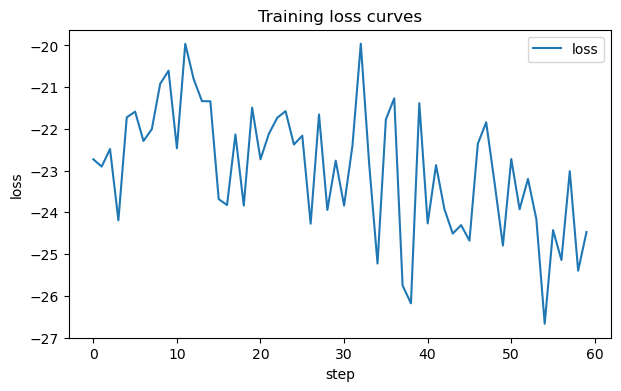

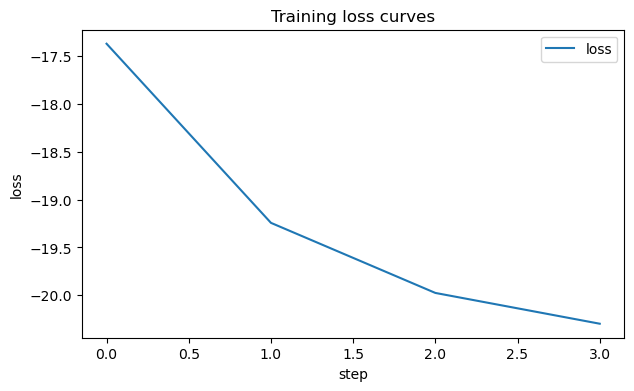

In [71]:

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(history["loss"], label="loss")
plt.xlabel("step")
plt.ylabel("loss")
plt.legend()
plt.title("Training loss curves")
plt.show()
plt.figure(figsize=(7, 4))
plt.plot(history["val_loss"], label="loss")
plt.xlabel("step")
plt.ylabel("loss")
plt.legend()
plt.title("Training loss curves")
plt.show()

[autoreload of surrogate_matlab failed: Traceback (most recent call last):
  File "D:\software\anaconda3\envs\PAT_new\lib\site-packages\IPython\extensions\autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "D:\software\anaconda3\envs\PAT_new\lib\site-packages\IPython\extensions\autoreload.py", line 500, in superreload
    update_generic(old_obj, new_obj)
  File "D:\software\anaconda3\envs\PAT_new\lib\site-packages\IPython\extensions\autoreload.py", line 397, in update_generic
    update(a, b)
  File "D:\software\anaconda3\envs\PAT_new\lib\site-packages\IPython\extensions\autoreload.py", line 349, in update_class
    if update_generic(old_obj, new_obj):
  File "D:\software\anaconda3\envs\PAT_new\lib\site-packages\IPython\extensions\autoreload.py", line 397, in update_generic
    update(a, b)
  File "D:\software\anaconda3\envs\PAT_new\lib\site-packages\IPython\extensions\autoreload.py", line 349, in update_class
    if update_generic(old_obj, new_obj):

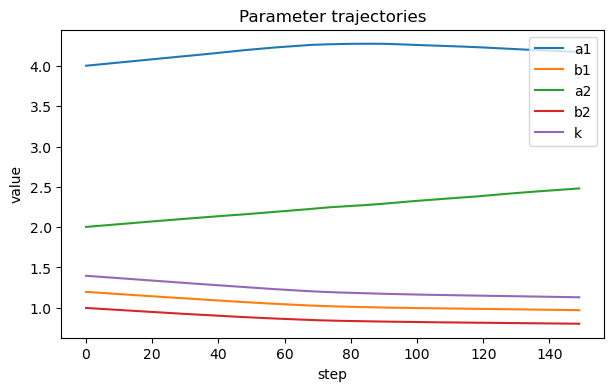

In [51]:
plt.figure(figsize=(7, 4))
plt.plot(history["a1"], label="a1")
plt.plot(history["b1"], label="b1")
plt.plot(history["a2"], label="a2")
plt.plot(history["b2"], label="b2")
plt.plot(history["k"], label="k")
plt.xlabel("step")
plt.ylabel("value")
plt.legend()
plt.title("Parameter trajectories")
plt.show()